<a href="https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-08/08-04-RNN-Daily-Temperature-Prediction-Regression-Project.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Build, train, and evaluate a vanilla recurrent neural network (RNN) in PyTorch to predict tomorrow's daily high temperature from the previous 14 days of weather data. This end-to-end regression project demonstrates synthetic time-series generation, sequence creation, proper train/test splitting, normalization without data leakage, RNN architecture, training with Mean Squared Error (MSE) loss and the Adam optimizer, gradient clipping, model evaluation using Mean Absolute Error (MAE), denormalization of predictions, and visualization of training and test learning curves.

RNN Temperature Prediction Pipeline

1. Loading and preparing temperature data...
Generated 365 days of synthetic temperature data.
Training days: 292
Testing days: 73
Training sequences: 278
Testing sequences: 73
Training mean: 72.93
Training standard deviation: 6.88

2. Creating RNN model...

3. Training model...

Model Architecture:
TemperatureRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

Starting Training...
Epoch [20/80], Train Loss: 0.0769, Test Loss: 0.0690
Epoch [40/80], Train Loss: 0.0571, Test Loss: 0.0644
Epoch [60/80], Train Loss: 0.0554, Test Loss: 0.0822
Epoch [80/80], Train Loss: 0.0526, Test Loss: 0.0696

Training Complete.

4. Evaluating model performance...

--- Test Predictions vs. Actual Values ---
Input last 5 days: [63.07, 66.2, 63.66, 63.34, 61.82] -> Actual: 60.99, Predicted: 61.66
Input last 5 days: [66.2, 63.66, 63.34, 61.82, 60.99] -> Actual: 61.72, Predicted: 62.13
Input last 5 days: [63.66, 63.34, 61

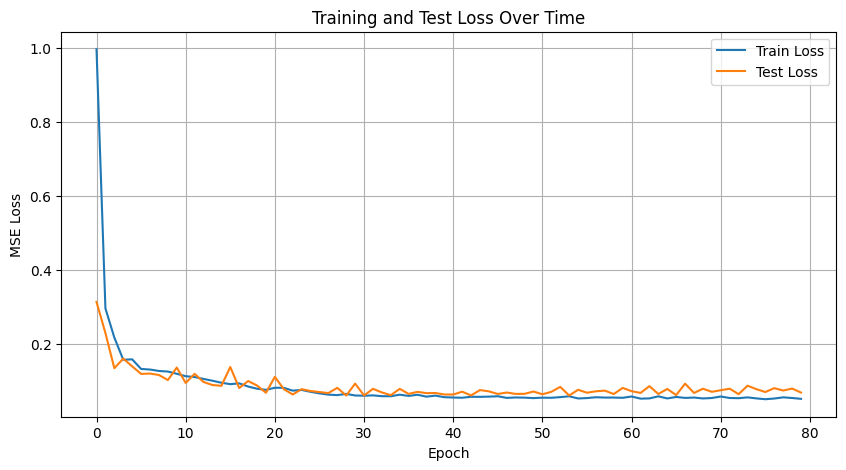


Temperature prediction complete!


In [3]:
# ==============================================================================
# 0. Imports
# ==============================================================================
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Set a random seed so the example is more reproducible.
# This makes the generated data and model initialization more consistent
# each time the code runs.
torch.manual_seed(42)

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

class Config:
    """Hyperparameters and settings for our temperature prediction model."""
    SEQUENCE_LENGTH = 14     # Use the previous 14 days to predict the next day
    HIDDEN_SIZE = 16         # RNN hidden state size
    NUM_LAYERS = 1           # Number of stacked RNN layers
    BATCH_SIZE = 32          # Training batch size
    LEARNING_RATE = 0.005    # Adam optimizer learning rate
    NUM_EPOCHS = 80          # Training epochs
    TRAIN_RATIO = 0.8        # 80% training, 20% testing
    NUM_DAYS = 365           # Generate one year of synthetic daily temperatures

config = Config()

# ==============================================================================
# 2. DATA PREPARATION
# ==============================================================================

class TemperatureDataset(Dataset):
    """
    Converts a temperature time series into sequences for RNN training.

    Each sample:
        [previous temperatures] -> [next temperature]

    For example, if sequence_length = 14:
        input  = temperatures from days 1-14
        target = temperature on day 15
    """

    def __init__(self, data, sequence_length):
        self.data = torch.tensor(data, dtype=torch.float32).view(-1, 1)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data) - self.sequence_length

    def __getitem__(self, idx):
        sequence = self.data[idx:idx + self.sequence_length]
        target = self.data[idx + self.sequence_length]
        return sequence, target


def generate_synthetic_temperatures(num_days=365):
    """
    Generate a simple synthetic temperature dataset.

    This gives the model enough data to learn from while keeping the example
    self-contained. The pattern includes:
    - yearly seasonality,
    - weekly variation,
    - a small warming trend,
    - random noise.

    In a real project, this function would be replaced with real weather data
    loaded from a CSV file, API, or database.
    """
    days = torch.arange(num_days, dtype=torch.float32)

    seasonal_pattern = 10 * torch.sin(2 * math.pi * days / 365)
    weekly_pattern = 2 * torch.sin(2 * math.pi * days / 7)
    slight_trend = 0.01 * days
    noise = torch.randn(num_days) * 1.5

    temperatures = 70 + seasonal_pattern + weekly_pattern + slight_trend + noise

    return temperatures


def prepare_data():
    """
    Prepare temperature data for RNN training.

    Important workflow:
    1. Generate or load the temperature time series.
    2. Split the data into training and test sets in time order.
    3. Compute normalization statistics using ONLY the training data.
    4. Normalize both training and test data using the SAME training statistics.
    5. Create PyTorch datasets and data loaders.

    Why normalize?
    RNNs internally use nonlinear activations such as tanh. Feeding raw values
    like 70-90 directly into the network can make training harder. Normalization
    rescales the values so they are centered closer to 0.

    Why compute mean/std from training data only?
    Computing statistics from the test set would leak information from the
    evaluation data into the training process. This is called data leakage.
    """
    temperatures = generate_synthetic_temperatures(num_days=config.NUM_DAYS)

    train_size = int(len(temperatures) * config.TRAIN_RATIO)

    train_temperatures = temperatures[:train_size]

    # Include the previous SEQUENCE_LENGTH values before the test period.
    # This gives the first test sequence enough history while still evaluating
    # only on targets from the test period.
    test_temperatures = temperatures[train_size - config.SEQUENCE_LENGTH:]

    # Compute normalization statistics using ONLY the training data.
    # These same values are reused for both training and test data.
    train_mean = train_temperatures.mean()
    train_std = train_temperatures.std()

    # Normalize both datasets using the training mean and training std.
    # The model will see normalized values during both training and evaluation.
    normalized_train = (train_temperatures - train_mean) / train_std
    normalized_test = (test_temperatures - train_mean) / train_std

    train_dataset = TemperatureDataset(
        normalized_train.tolist(),
        config.SEQUENCE_LENGTH
    )

    test_dataset = TemperatureDataset(
        normalized_test.tolist(),
        config.SEQUENCE_LENGTH
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )

    print(f"Generated {len(temperatures)} days of synthetic temperature data.")
    print(f"Training days: {len(train_temperatures)}")
    print(f"Testing days: {len(temperatures) - train_size}")
    print(f"Training sequences: {len(train_dataset)}")
    print(f"Testing sequences: {len(test_dataset)}")
    print(f"Training mean: {train_mean:.2f}")
    print(f"Training standard deviation: {train_std:.2f}")

    return train_loader, test_loader, test_dataset, train_mean, train_std

# ==============================================================================
# 3. RNN MODEL ARCHITECTURE
# ==============================================================================

class TemperatureRNN(nn.Module):
    """
    Vanilla RNN model for temperature prediction.

    Architecture:
        Input sequence -> RNN layer -> final hidden state -> Linear output layer
    """

    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(TemperatureRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Forward pass: sequence -> hidden states -> final prediction.

        Input shape:
            (batch_size, sequence_length, input_size)

        Output shape:
            (batch_size, output_size)
        """
        batch_size = x.size(0)

        # A vanilla RNN needs only a hidden state, h0.
        # Unlike an LSTM, it does not use a separate cell state.
        h0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_size,
            device=x.device
        )

        rnn_out, hn = self.rnn(x, h0)

        # Use the output from the final time step because it summarizes
        # information from the whole input sequence.
        final_hidden_state = rnn_out[:, -1, :]

        prediction = self.fc(final_hidden_state)

        return prediction

# ==============================================================================
# 4. TRAINING PIPELINE
# ==============================================================================

def train_model(model, train_loader, test_loader):
    """
    Train the RNN model with backpropagation through time.

    We track both training loss and test loss so we can see whether the model
    is learning and whether it generalizes reasonably to unseen data.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

    train_losses = []
    test_losses = []

    print("\nModel Architecture:")
    print(model)

    print("\nStarting Training...")

    for epoch in range(config.NUM_EPOCHS):
        # ------------------------------
        # Training phase
        # ------------------------------
        model.train()
        train_loss = 0

        for batch_data, batch_targets in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_data)

            loss = criterion(predictions, batch_targets)

            loss.backward()

            # Gradient clipping helps prevent exploding gradients, which can
            # occur in recurrent networks when gradients grow too large during
            # backpropagation through time.
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        train_losses.append(train_loss)

        # ------------------------------
        # Evaluation phase during training
        # ------------------------------
        model.eval()
        test_loss = 0

        # During evaluation, we do not update weights, so gradients are not needed.
        with torch.no_grad():
            for test_data, test_targets in test_loader:
                test_predictions = model(test_data)
                loss = criterion(test_predictions, test_targets)
                test_loss += loss.item()

        test_loss = test_loss / len(test_loader)
        test_losses.append(test_loss)

        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch [{epoch + 1}/{config.NUM_EPOCHS}], "
                f"Train Loss: {train_loss:.4f}, "
                f"Test Loss: {test_loss:.4f}"
            )

    print("\nTraining Complete.")

    return train_losses, test_losses

# ==============================================================================
# 5. MODEL EVALUATION
# ==============================================================================

def evaluate_model(model, test_dataset, train_mean, train_std, num_examples=10):
    """
    Evaluate the trained model on unseen test data.

    Important:
    - The model receives normalized inputs.
    - The model produces normalized predictions.
    - We denormalize predictions and targets only when displaying them,
      so the results are shown in degrees Fahrenheit.
    """
    model.eval()

    print("\n--- Test Predictions vs. Actual Values ---")

    absolute_errors = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sequence, target = test_dataset[i]

            # The sequence is already normalized because test_dataset was created
            # from normalized_test in prepare_data().
            sequence_input = sequence.unsqueeze(0)

            # The prediction is also in normalized temperature units.
            prediction = model(sequence_input)

            # Denormalize the target and prediction back to degrees Fahrenheit.
            actual_value = target.item() * train_std.item() + train_mean.item()
            predicted_value = prediction.item() * train_std.item() + train_mean.item()

            absolute_errors.append(abs(predicted_value - actual_value))

            if i < num_examples:
                # Denormalize input values only for display.
                input_values = (sequence.squeeze() * train_std + train_mean).tolist()
                last_five_inputs = [round(x, 2) for x in input_values[-5:]]

                print(
                    f"Input last 5 days: {last_five_inputs} -> "
                    f"Actual: {actual_value:.2f}, "
                    f"Predicted: {predicted_value:.2f}"
                )

    mae = sum(absolute_errors) / len(absolute_errors)

    print(f"\nMean Absolute Error on test set: {mae:.2f} degrees")

    return mae


def plot_losses(train_losses, test_losses):
    """
    Plot training and test loss over time.

    This helps us see whether the model is learning:
    - If both losses decrease, the model is improving.
    - If training loss decreases but test loss increases, the model may be overfitting.
    - If both losses stay high, the model may be underfitting.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training and Test Loss Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==============================================================================
# 6. MAIN EXECUTION FLOW
# ==============================================================================

def main():
    """
    Complete pipeline for temperature prediction with a vanilla RNN.

    This project demonstrates:
    - creating a larger synthetic time-series dataset,
    - splitting data in time order,
    - normalizing without data leakage,
    - training a vanilla RNN,
    - using gradient clipping,
    - evaluating on unseen test data,
    - plotting the learning curve.
    """
    print("RNN Temperature Prediction Pipeline")

    print("\n1. Loading and preparing temperature data...")
    train_loader, test_loader, test_dataset, train_mean, train_std = prepare_data()

    print("\n2. Creating RNN model...")
    model = TemperatureRNN(
        input_size=1,
        hidden_size=config.HIDDEN_SIZE,
        num_layers=config.NUM_LAYERS,
        output_size=1
    )

    print("\n3. Training model...")
    train_losses, test_losses = train_model(model, train_loader, test_loader)

    print("\n4. Evaluating model performance...")
    evaluate_model(model, test_dataset, train_mean, train_std)

    print("\n5. Plotting learning curve...")
    plot_losses(train_losses, test_losses)

    print("\nTemperature prediction complete!")

if __name__ == "__main__":
    main()
